In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
# Normalize values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [4]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9223 - loss: 0.2684 - val_accuracy: 0.9609 - val_loss: 0.1324
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9655 - loss: 0.1129 - val_accuracy: 0.9670 - val_loss: 0.1078
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0761 - val_accuracy: 0.9705 - val_loss: 0.1007
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9808 - loss: 0.0587 - val_accuracy: 0.9740 - val_loss: 0.0893
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0453 - val_accuracy: 0.9707 - val_loss: 0.0985
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9890 - loss: 0.0348 - val_accuracy: 0.9731 - val_loss: 0.0965
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9903 - loss: 0.0299 - val_accuracy: 0.9742 - val_loss: 0.1029
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9921 - loss: 0.0236 - 

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0925
Test Accuracy: 0.9785000085830688


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


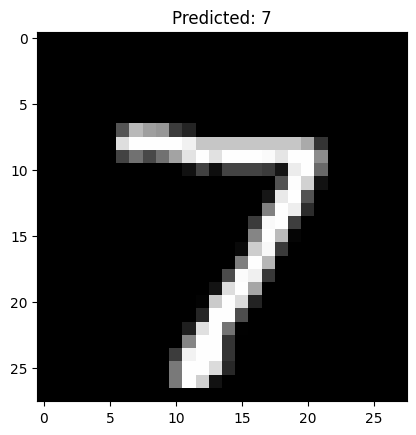

In [8]:
predictions = model.predict(x_test)

# Show prediction for first image
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[0])))
plt.show()

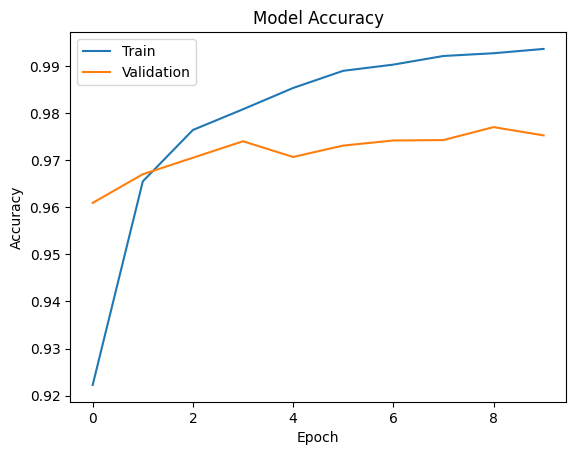

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# 📘 Cell-wise Explanation of ANN using Keras/TensorFlow

### 🔹 Cell 1: Import Libraries

This cell imports all required libraries.

* **TensorFlow/Keras** is used to build and train the Artificial Neural Network.
* **NumPy** is used for numerical operations.
* **Matplotlib** is used for plotting graphs such as accuracy curves.

---

### 🔹 Cell 2: Load Dataset

The MNIST dataset is loaded using Keras built-in datasets.

* It contains handwritten digit images (0–9).
* The dataset is split into **training data (60,000 images)** and **testing data (10,000 images)**.
* Each image is of size **28 × 28 pixels**.

---

### 🔹 Cell 3: Data Preprocessing

This step prepares the data for training.

* Pixel values are normalized from **0–255 to 0–1** to improve model performance.
* Images are flattened from **28×28 matrices into 1D arrays of size 784**, because ANN requires vector input.

---

### 🔹 Cell 4: Build ANN Model

A Sequential model is created with multiple layers:

* First hidden layer: **128 neurons with ReLU activation**
* Second hidden layer: **64 neurons with ReLU activation**
* Output layer: **10 neurons with Softmax activation** (for digit classification)
  This defines the architecture of the neural network.

---

### 🔹 Cell 5: Compile Model

The model is configured for training.

* **Optimizer:** Adam (efficient gradient descent method)
* **Loss Function:** Sparse categorical crossentropy (used for multi-class classification)
* **Metrics:** Accuracy (to evaluate performance)

---

### 🔹 Cell 6: Train Model

The model is trained using the training dataset.

* The training runs for **10 epochs** (iterations over the dataset).
* **Validation split (20%)** is used to check model performance on unseen training data during training.
* The model learns patterns in the handwritten digits.

---

### 🔹 Cell 7: Evaluate Model

The trained model is tested on the test dataset.

* It calculates **test accuracy and loss**.
* This shows how well the model generalizes to new data.

---

### 🔹 Cell 8: Predictions

The model predicts outputs for test images.

* The predicted class is obtained using **argmax()** (highest probability).
* The first test image is displayed along with its predicted label.

---

### 🔹 Cell 9: Plot Accuracy Graph

A graph is plotted to visualize model performance.

* Training accuracy and validation accuracy are shown.
* Helps to identify overfitting or underfitting.

---

# ✅ Conclusion

The Artificial Neural Network was successfully implemented using Keras.
The model achieved high accuracy in classifying handwritten digits and demonstrated the effectiveness of ANN in image classification tasks.


# 📊 Dataset Description: MNIST Dataset

### 📌 Description

The MNIST dataset is a standard benchmark dataset in machine learning, consisting of grayscale images of handwritten digits from 0 to 9. It is widely used for training and testing image classification models, especially Artificial Neural Networks (ANNs).

### 📊 Features

* Each sample is a **28 × 28 pixel grayscale image**
* Pixel intensity values range from **0 to 255**
* After preprocessing, each image is flattened into a **784-dimensional vector (28×28)**

### 🎯 Target Variable

* The target variable is a **digit label (0–9)** corresponding to the image
* Type: **Multi-class classification (10 classes)**

### 📦 Dataset Size

* Training samples: **60,000 images**
* Testing samples: **10,000 images**
* Total samples: **70,000 images**

### ⭐ Key Characteristics

* Clean and noise-free dataset
* Balanced distribution across all digit classes
* Low complexity, suitable for beginners
* Widely used for benchmarking classification algorithms
